# Predicting Drinking Water Potability from Chemical Properties
**Practical Machine Learning — Green Data Science 2025/2026**  
Luís Vale — 25952  Dataset:** [Water Quality and Potability — Kaggle](https://www.kaggle.com/datasets/adityakadiwal/water-potability)

---

## Table of Contents
1. [Setup & Imports](#1-setup)
2. [Data Loading & Exploration](#2-eda)
3. [Data Cleaning & Preprocessing](#3-preprocessing)
4. [Data Organisation (Train/Val/Test)](#4-splits)
5. [Model Training & Hyperparameter Tuning](#5-models)
6. [Evaluation & Results](#6-evaluation)
7. [Feature Importance & SHAP](#7-shap)
8. [Conclusions](#8-conclusions)

## 1. Setup & Imports <a id='1-setup'></a>

In [1]:
# !pip install shap xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, cross_val_score, learning_curve
)

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Sklearn — metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, roc_curve,
    precision_score, recall_score, matthews_corrcoef
)
from sklearn.inspection import permutation_importance

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading & Exploratory Analysis <a id='2-eda'></a>

In [2]:
# Load dataset — place water_potability.csv in the same directory


df = pd.read_csv('water_potability.csv')

print('Shape:', df.shape)
print('\nFirst rows:')
df.head()

Shape: (3276, 10)

First rows:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Basic info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [4]:
# Descriptive statistics
df.describe().round(2)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.00,3276.00,3276.00,3276.00,2495.00,3276.00,3276.00,3114.00,3276.00,3276.00
mean,7.08,196.37,22014.09,7.12,333.78,426.21,14.28,66.40,3.97,0.39
std,1.59,32.88,8768.57,1.58,41.42,80.82,3.31,16.18,0.78,0.49
min,0.00,47.43,320.94,0.35,129.00,181.48,2.20,0.74,1.45,0.00
25%,6.09,176.85,15666.69,6.13,307.70,365.73,12.07,55.84,3.44,0.00
50%,7.04,196.97,20927.83,7.13,333.07,421.88,14.22,66.62,3.96,0.00
75%,8.06,216.67,27332.76,8.11,359.95,481.79,16.56,77.34,4.50,1.00
max,14.00,323.12,61227.20,13.13,481.03,753.34,28.30,124.00,6.74,1.00


In [5]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_pct})
print('Missing values per feature:')
print(missing_df[missing_df['Missing'] > 0])

Missing values per feature:
                 Missing  Percentage (%)
ph                   491            15.0
Sulfate              781            23.8
Trihalomethanes      162             4.9


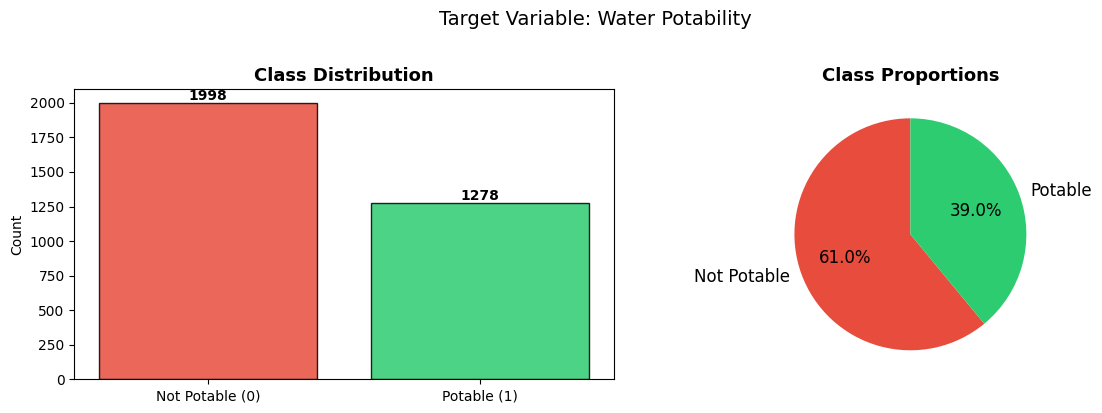

Class imbalance ratio: 1.56:1 (Not Potable : Potable)


In [6]:
# Class distribution (target variable)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['Potability'].value_counts()
axes[0].bar(['Not Potable (0)', 'Potable (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Not Potable', 'Potable'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Water Potability', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class imbalance ratio: {counts[0]/counts[1]:.2f}:1 (Not Potable : Potable)')

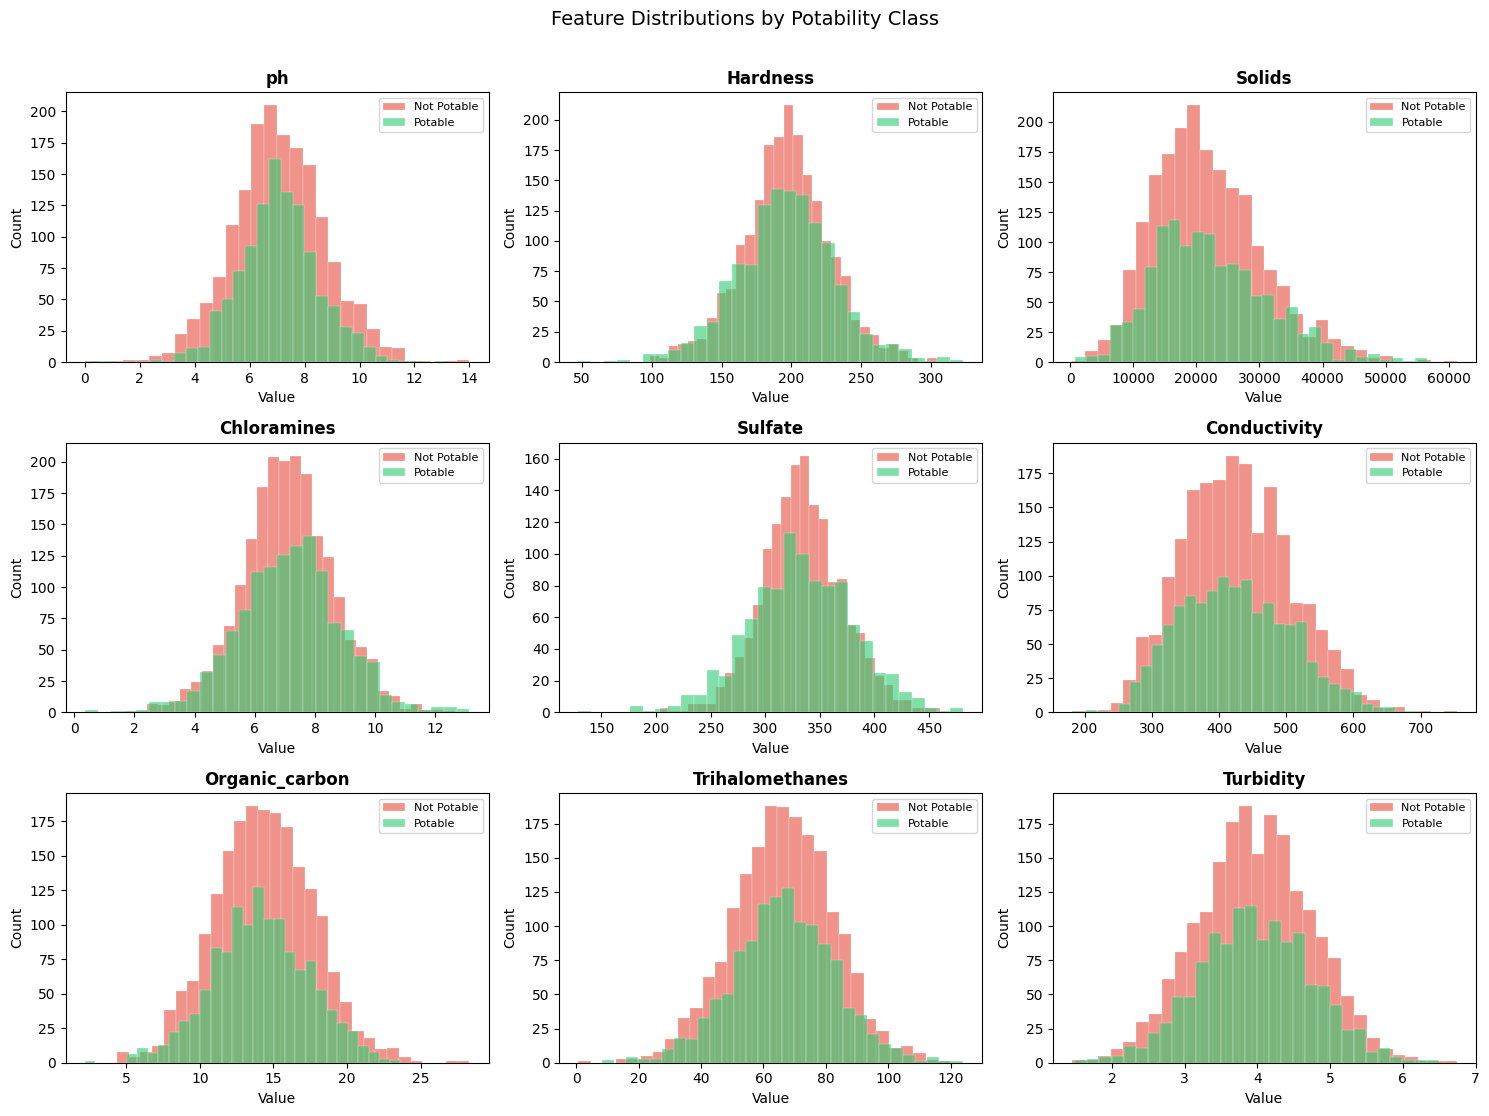

In [7]:
# Feature distributions by class
features = [c for c in df.columns if c != 'Potability']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, color, name in zip([0, 1], ['#e74c3c', '#2ecc71'],
                                   ['Not Potable', 'Potable']):
        subset = df[df['Potability'] == label][feat].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label=name, edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions by Potability Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

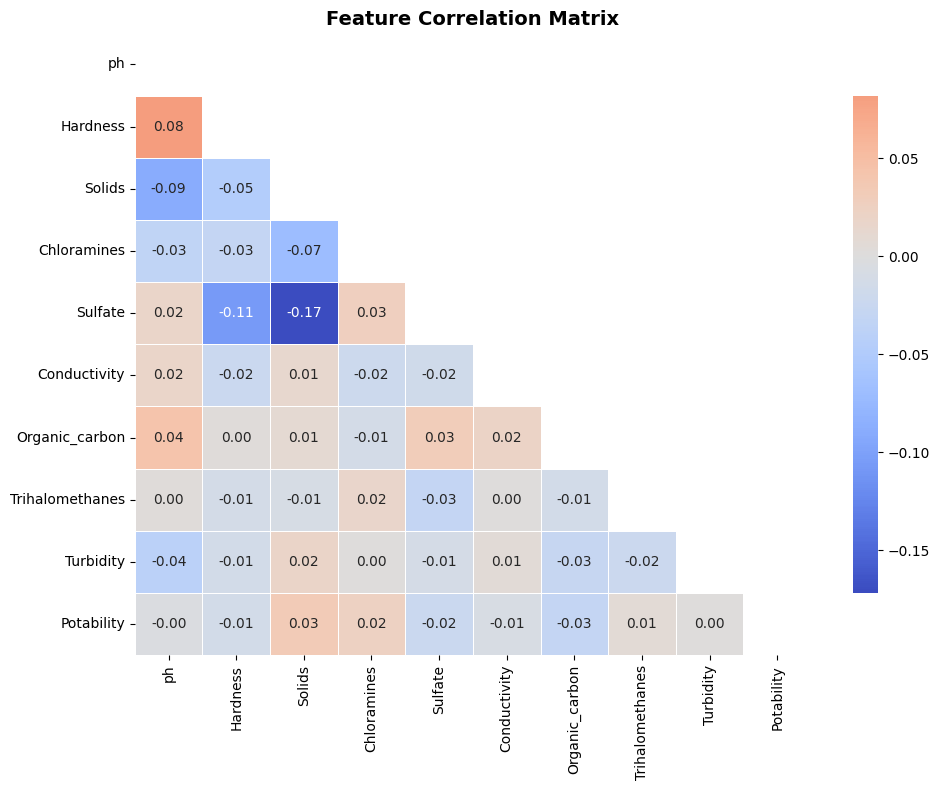

In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Cleaning & Preprocessing <a id='3-preprocessing'></a>

Missing values are imputed using the **median** (robust to outliers).  
Crucially, imputation statistics are computed **only on the training set** and then applied to validation/test — this is handled automatically by placing the imputer inside a **sklearn Pipeline**, preventing data leakage.

In [9]:
# Separate features and target
X = df.drop('Potability', axis=1)
y = df['Potability']

print('Features shape:', X.shape)
print('Target distribution:\n', y.value_counts())

Features shape: (3276, 9)
Target distribution:
 Potability
0    1998
1    1278
Name: count, dtype: int64


## 4. Data Organisation — Train / Validation / Test Split <a id='4-splits'></a>

In [10]:
# Step 1: Hold out 20% as the final test set (stratified to preserve class balance)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Step 2: From remaining 80%, hold out 20% as validation set for model selection
# (= 16% of total data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.20, random_state=SEED, stratify=y_train_val
)

print('Dataset split summary:')
print(f'  Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'  Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nClass balance in test set:')
print(y_test.value_counts(normalize=True).round(3))

Dataset split summary:
  Training set:   2096 samples (64%)
  Validation set: 524 samples (16%)
  Test set:       656 samples (20%)

Class balance in test set:
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


## 5. Model Training & Hyperparameter Tuning <a id='5-models'></a>

Three models are trained and compared:
**Logistic Regression** — simple linear baseline
**Random Forest** — ensemble of independent decision trees
**XGBoost** — sequential gradient boosting with regularisation

Each model is wrapped in a **Pipeline**: `Imputer → Scaler → Model`.  
Hyperparameters are tuned with **GridSearchCV** using **StratifiedKFold (k=5)**,  
optimising for **F1-score** (appropriate for imbalanced classes).

In [11]:
# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Pipeline builder helper
def build_pipeline(model):
    """Chains imputation → scaling → model. Prevents data leakage."""
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model)
    ])

print('Pipeline builder ready.')

Pipeline builder ready.


In [12]:
# 5.1 Logistic Regression (Baseline)
lr_pipeline = build_pipeline(
    LogisticRegression(max_iter=1000, random_state=SEED)
)

# prompt: Define hyperparameter grid and run GridSearchCV for Logistic Regression
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

lr_gs = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
lr_gs.fit(X_train, y_train)

print('Best LR params:', lr_gs.best_params_)
print(f'Best CV F1:     {lr_gs.best_score_:.4f}')

Best LR params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV F1:     0.0024


In [13]:
# 5.2 Random Forest
rf_pipeline = build_pipeline(
    RandomForestClassifier(random_state=SEED)
)

# prompt: Define a hyperparameter grid and run GridSearchCV for Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [None, 5, 10],
    'model__min_samples_leaf': [1, 5],
    'model__max_features': ['sqrt', 0.5]
}

rf_gs = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
rf_gs.fit(X_train, y_train)

print('Best RF params:', rf_gs.best_params_)
print(f'Best CV F1:     {rf_gs.best_score_:.4f}')

Best RF params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Best CV F1:     0.4165


In [14]:
# 5.3 XGBoost
xgb_pipeline = build_pipeline(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=SEED)
)

# prompt: Define hyperparameter grid and run GridSearchCV for XGBoost
xgb_param_grid = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample':     [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_gs = GridSearchCV(
    xgb_pipeline, xgb_param_grid,
    cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
xgb_gs.fit(X_train, y_train)

print('Best XGB params:', xgb_gs.best_params_)
print(f'Best CV F1:      {xgb_gs.best_score_:.4f}')

Best XGB params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV F1:      0.4779


## 6. Evaluation & Results <a id='6-evaluation'></a>

In [15]:
# prompt: Compute all evaluation metrics for all three models on the test set
def evaluate_model(name, gs, X_test, y_test):
    """Returns a dict of metrics for a fitted GridSearchCV pipeline."""
    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:, 1]
    return {
        'Model':     name,
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'MCC':       round(matthews_corrcoef(y_test, y_pred), 4)
    }

results = [
    evaluate_model('Logistic Regression', lr_gs,  X_test, y_test),
    evaluate_model('Random Forest',       rf_gs,  X_test, y_test),
    evaluate_model('XGBoost',             xgb_gs, X_test, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print('=== Test Set Results ===')
results_df

=== Test Set Results ===


,F1,ROC-AUC,Precision,Recall,MCC
Model,,,,,
Logistic Regression,0.0000,0.5458,0.0000,0.0000,0.0000
Random Forest,0.4053,0.6407,0.6210,0.3008,0.2284
XGBoost,0.4481,0.6243,0.5655,0.3711,0.2108


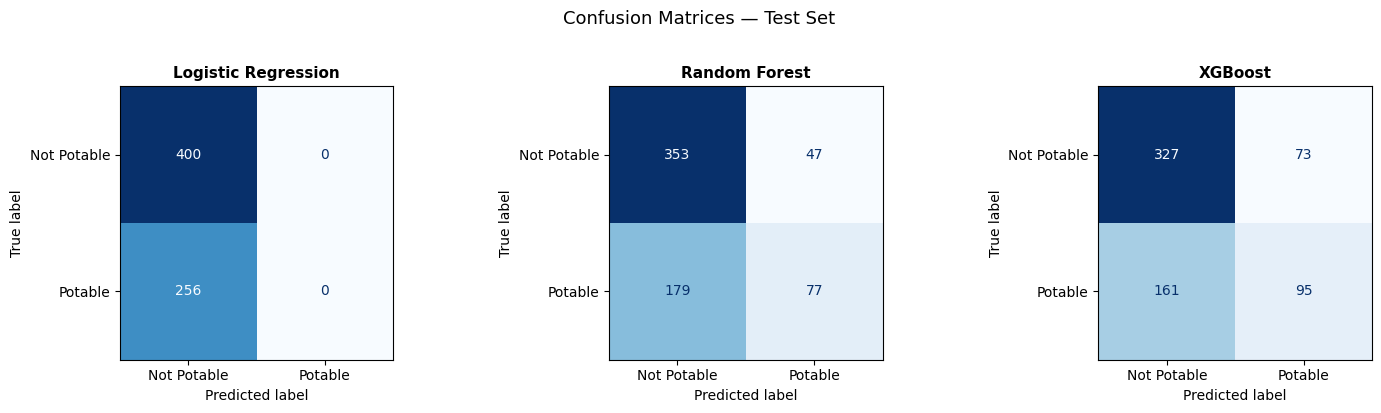

In [16]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    ('Logistic Regression', lr_gs),
    ('Random Forest',       rf_gs),
    ('XGBoost',             xgb_gs)
]

for ax, (name, gs) in zip(axes, models_info):
    y_pred = gs.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Potable', 'Potable'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

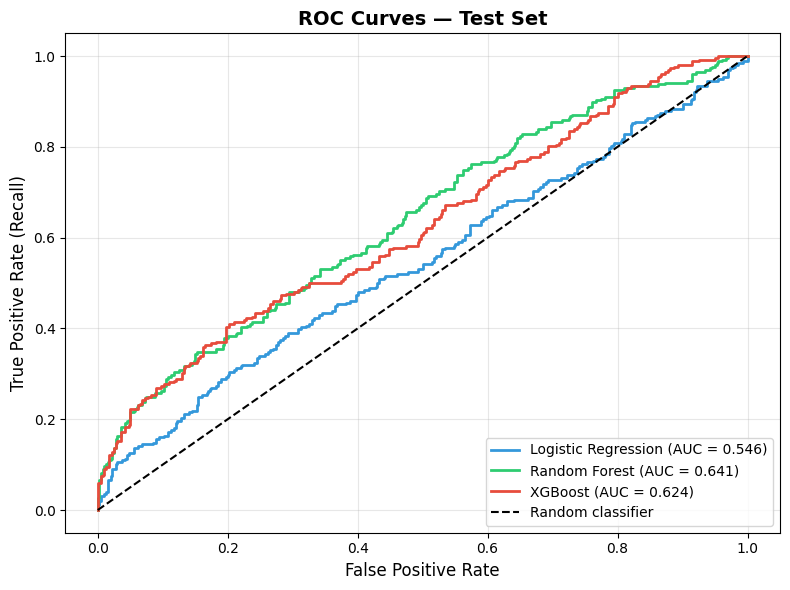

In [17]:
# ROC curves for all three models
plt.figure(figsize=(8, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, gs), color in zip(models_info, colors):
    y_prob = gs.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — Test Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Detailed classification report for the best model
# update 'best_gs' to whichever model performed best above
best_gs   = xgb_gs     # <-- change if RF wins
best_name = 'XGBoost'  # <-- change accordingly

y_pred_best = best_gs.predict(X_test)
print(f'=== {best_name} — Full Classification Report ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['Not Potable', 'Potable']))

=== XGBoost — Full Classification Report ===
              precision    recall  f1-score   support

 Not Potable       0.67      0.82      0.74       400
     Potable       0.57      0.37      0.45       256

    accuracy                           0.64       656
   macro avg       0.62      0.59      0.59       656
weighted avg       0.63      0.64      0.62       656



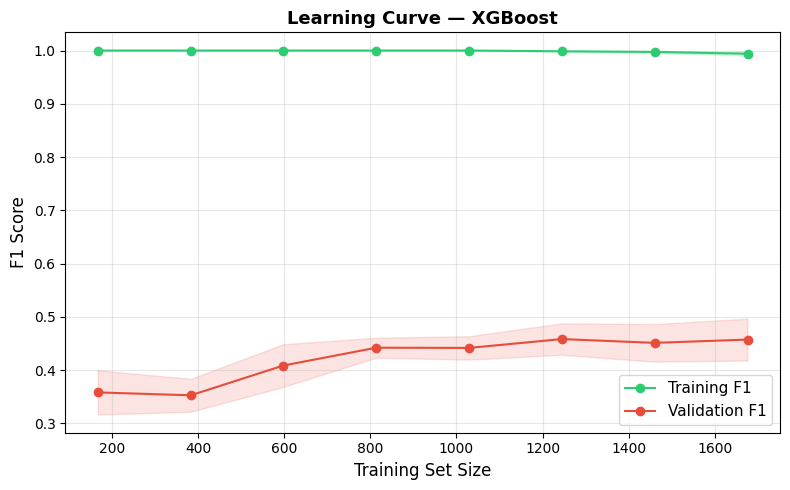

In [19]:
# Learning curve for the best model
# prompt: Plot learning curve to assess overfitting / underfitting
train_sizes, train_scores, val_scores = learning_curve(
    best_gs.best_estimator_, X_train, y_train,
    cv=cv, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Training F1')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='#2ecc71')
plt.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation F1')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='#e74c3c')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title(f'Learning Curve — {best_name}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance & SHAP <a id='7-shap'></a>

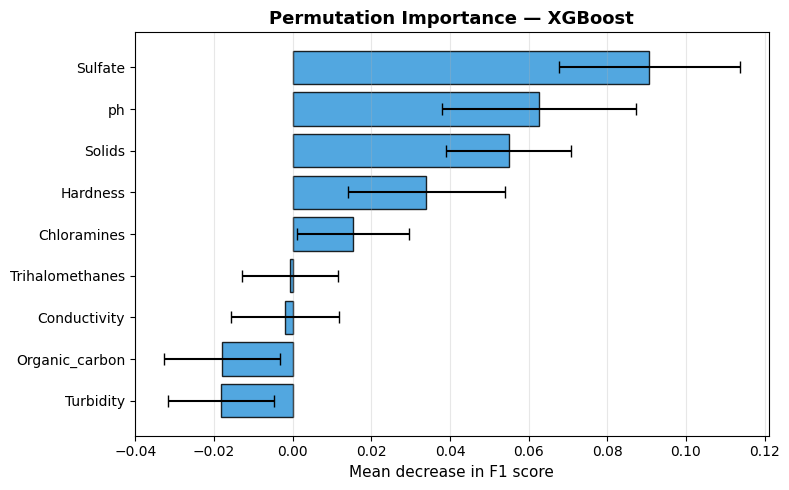

In [20]:
# Permutation Importance (model-agnostic, computed on test set)
# prompt: Compute and plot permutation importance for the best model on the test set

# Preprocess X_test through the pipeline steps (imputer + scaler)
# then run permutation importance on the final estimator
pipe = best_gs.best_estimator_
X_test_transformed = pipe[:-1].transform(X_test)  # apply imputer + scaler

perm_imp = permutation_importance(
    pipe[-1], X_test_transformed, y_test,
    n_repeats=30, random_state=SEED, scoring='f1'
)

perm_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': perm_imp.importances_mean,
    'Std':        perm_imp.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
         xerr=perm_df['Std'][::-1], color='#3498db', alpha=0.85,
         edgecolor='black', capsize=4)
plt.xlabel('Mean decrease in F1 score', fontsize=11)
plt.title(f'Permutation Importance — {best_name}', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

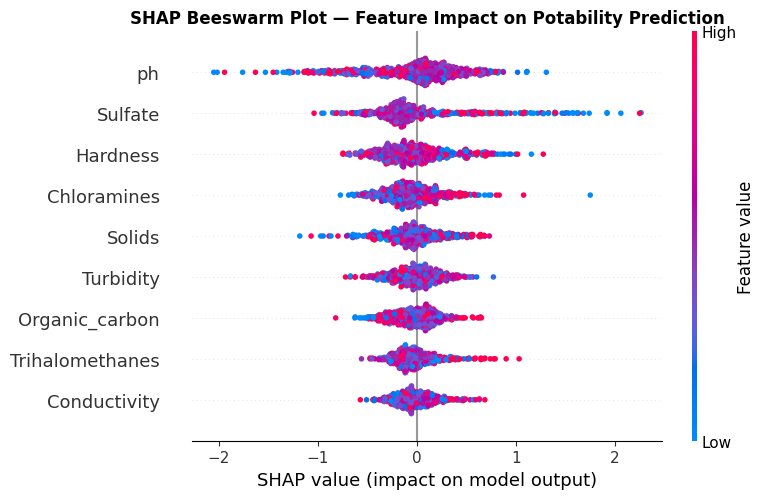

In [21]:
# SHAP values — explains individual predictions
# prompt: Compute SHAP values for XGBoost and produce summary + beeswarm plots

# Use the fitted XGBoost model inside the pipeline
xgb_model = best_gs.best_estimator_['model']

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

feature_names = list(X.columns)

# --- SHAP beeswarm plot ---
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Beeswarm Plot — Feature Impact on Potability Prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

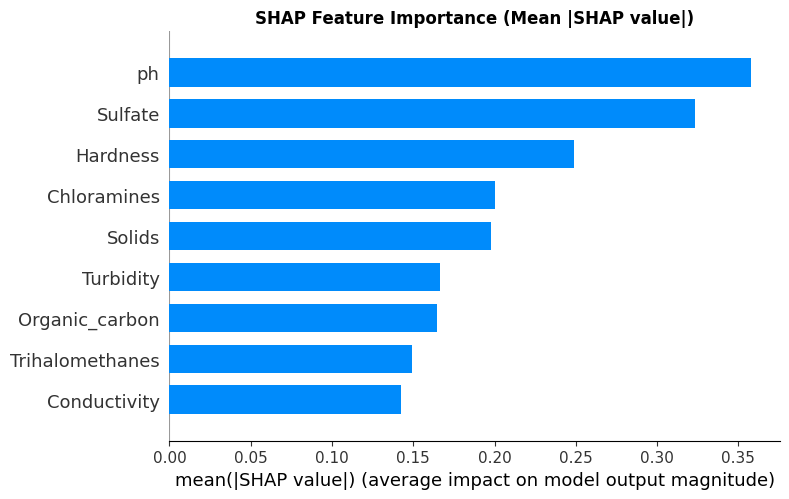

In [22]:
# SHAP bar plot — mean absolute SHAP value per feature
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()